In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
grassknoted_asl_alphabet_path = kagglehub.dataset_download('grassknoted/asl-alphabet')

print('Data source import complete.')


Using Colab cache for faster access to the 'asl-alphabet' dataset.
Data source import complete.


<h2><center>American Sign Language Detection</center></h2>

***I've added the final model as a dataset link. Since running this notebook requires GPU consumtion and it's quite time consuming, if you just want the model, you may get it from here https://www.kaggle.com/namanmanchanda/american-sign-language-model-99-accuracy.***

Table of contents <a id=19></a>
1. [Importing packages](#1)
2. [Importing the dataset from training directory](#2)
    - 2.1 [Checking the shape of data](#3)
    - 2.2 [Checking the shape of one image](#4)
    - 2.3 [Viewing the image](#5)
3. [Data processing](#6)
    - 3.1 [Train/test split](#7)
    - 3.2 [One-Hot-Encoding](#8)
    - 3.3 [Dimension Check of variables](#9)
4. [Garbage Collection](#10)
5. [Modeling](#11)
    - 5.1 [Importing packages](#12)
    - 5.2 [Building the model](#13)
    - 5.3 [Early Stopping & Compiling](#14)
    - 5.4 [Model fitting](#15)
    - 5.5 [Model metrics](#16)
    - 5.6 [Predictions](#17)
    - 5.7 [Saving the model](#18)

### 1. Importing packages <a id=1></a>

In [3]:
# import data processing and visualisation libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# import image processing libraries
import cv2
import skimage
from skimage.transform import resize

# import tensorflow and keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers, callbacks

import os, gc

print("Packages imported...")


Packages imported...


### 2. Importing the dataset from training directory <a id=2></a>

In [4]:
batch_size = 32
imageSize = 224
target_dims = (imageSize, imageSize, 3)
num_classes = 29
validation_split = 0.2

train_dir = '/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train/'

# --- Data augmentation for training ---
train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,  # keeps compatibility with MobileNetV2
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# --- Validation (rescale only) ---
val_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(imageSize, imageSize),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(imageSize, imageSize),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Quick info
num_classes = len(train_generator.class_indices)
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Classes: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}
Train samples: 69600
Validation samples: 17400
Num GPUs Available: 1


#### 2.1 Checking the shape of data <a id=3></a>



In [ ]:
# One batch of images and labels
x_batch, y_batch = next(train_generator)
print("Batch of images shape:", x_batch.shape)   # (batch_size, 64, 64, 3)
print("Batch of labels shape:", y_batch.shape)   # (batch_size, num_classes)


Batch of images shape: (32, 224, 224, 3)
Batch of labels shape: (32, 29)


#### 2.2 Checking the shape of one image <a id=4></a>

In [ ]:
print("Single image shape:", x_batch[0].shape)   # should be (64, 64, 3)


Single image shape: (224, 224, 3)


#### 2.3 Viewing the image <a id=5></a>

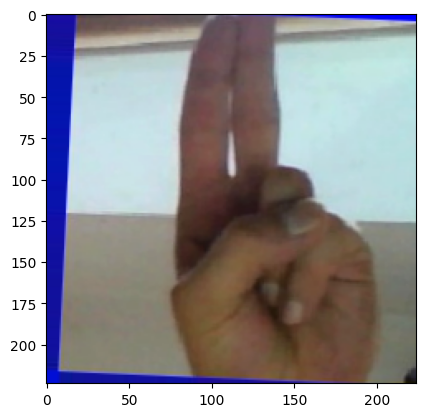

In [ ]:
plt.imshow((x_batch[0] + 1) / 2)  # bring back to [0,1]
plt.show()

##### 2.3.1 Making copies of original data

In [ ]:
X_data = x_batch
y_data = y_batch
print("Copies made...")

Copies made...


### 3. Data processing <a id=6></a>

#### 3.1 Train/test split <a id=7></a>

In [ ]:
print("Train batches:", len(train_generator))
print("Validation batches:", len(val_generator))


Train batches: 2175
Validation batches: 544


#### 3.2 One-Hot-Encoding <a id=8></a>

In [ ]:
x_batch, y_batch = next(train_generator)
print("Label vector (one-hot):", y_batch[0])
print("Decoded label index:", np.argmax(y_batch[0]))


Label vector (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
Decoded label index: 18


#### 3.3 Dimension Check of variables <a id=9></a>

In [ ]:
print("Input batch shape:", x_batch.shape)   # (batch_size, 64, 64, 3)
print("Output batch shape:", y_batch.shape)  # (batch_size, num_classes)


Input batch shape: (32, 224, 224, 3)
Output batch shape: (32, 29)


### 4. Garbage Collection <a id=10></a>

In [ ]:
# This is done to save CPU and RAM space while working on Kaggle Kernels. This will delete the specified data and save some space!
import gc
gc.collect()

3682

### 5. Modeling <a id=11></a>

#### 5.1 Importing packages <a id=12></a>

In [ ]:
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2

print("Packages imported...")

Packages imported...


#### 5.2 Building model <a id=13></a>

In [ ]:
def build_model(input_shape=(64,64,3), num_classes=num_classes):
    base_model = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze base layers
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,397 (9.90 MB)

 Trainable params: 335,901 (1.28 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

#### 5.3 Early Stopping and Compiling <a id=14></a>

##### 5.3.1 Early Stopping

Early Stopping is done to make sure the model fitting stops at the most optimized accuracy point. After the early stopping point, the model might start overfitting. For testing purposes, this step can be skipped and complete training can be done.

In [ ]:
from tensorflow.keras import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


##### 5.3.2 Compiling

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_asl_model.h5", monitor="val_loss", save_best_only=True, verbose=1
)

lr_schedule = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, verbose=1
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


#### 5.4 Model fitting <a id=15></a>

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, checkpoint, lr_schedule]
)

Epoch 1/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.7652 - loss: 0.7486
Epoch 1: val_loss improved from inf to 0.51062, saving model to best_asl_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1083s 498ms/step - accuracy: 0.7652 - loss: 0.7486 - val_accuracy: 0.8485 - val_loss: 0.5106 - learning_rate: 0.0010
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.8136 - loss: 0.5845
Epoch 2: val_loss improved from 0.51062 to 0.50717, saving model to best_asl_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 951s 437ms/step - accuracy: 0.8136 - loss: 0.5845 - val_accuracy: 0.8528 - val_loss: 0.5072 - learning_rate: 0.0010
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8290 - loss: 0.5341
Epoch 3: val_loss improved from 0.50717 to 0.45272, saving model to best_asl_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 944s 434ms/step - accuracy: 0.8290 - loss: 0.5341 - val_accuracy: 0.8665 - val_loss: 0.4527 - learning_rate: 0.0010
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8378 - loss: 0.5020
Epoch 4: val_loss improved from 0.45272 to 0.43974, saving model to best_asl_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 966s 444ms/step - accuracy: 0.8378 - loss: 0.5020 - val_accuracy: 0.8712 - val_loss: 0.4397 - learning_rate: 0.0010
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8414 - loss: 0.4980
Epoch 5: val_loss did not improve from 0.43974
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 952s 437ms/step - accuracy: 0.8414 - loss: 0.4980 - val_accuracy: 0.8563 - val_loss: 0.4697 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


#### 5.5 Model metrics <a id=16></a>

##### 5.5.1 Metrics from model history

In [ ]:
metrics = pd.DataFrame(model.history.history)
print("The model metrics are")
metrics

The model metrics are


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.785761,0.679250,0.848506,0.510617,0.001
1,0.817586,0.571740,0.852816,0.507165,0.001
2,0.829440,0.531681,0.866494,0.452718,0.001
3,0.839512,0.499226,0.871207,0.439738,0.001
4,0.842328,0.491071,0.856322,0.469691,0.001


##### 5.5.2 Plotting the training loss

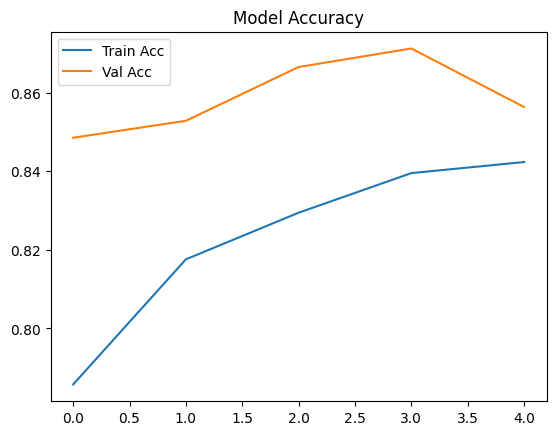

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Model Accuracy")
plt.show()

##### 5.5.3 Plotting the testing loss

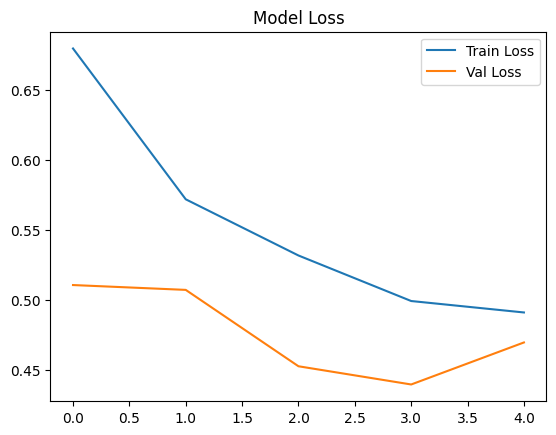

In [ ]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

##### 5.5.4 Model evaluation

In [ ]:
model.evaluate(val_generator, verbose=1)

544/544 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.9080 - loss: 0.3186


[0.4397377073764801, 0.8712068796157837]

#### 5.6 Predictions <a id=17></a>

In [1]:
y_true = val_generator.classes
y_pred = model.predict(val_generator).argmax(axis=1)
print("Predictions done...")

NameError: name 'val_generator' is not defined

##### 5.6.1 Classification report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(val_generator.classes, y_pred, target_names=list(val_generator.class_indices.keys())))

##### 5.6.2 Confusion matrix heatmap

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15,15))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.show()

#### 5.7 Saving the model <a id=18></a>

In [ ]:
from keras.models import load_model
model.save('my_model.keras')
print("Model saved successfully...")

NameError: name 'model' is not defined

[back to top](#19)

### If you liked the notebook, consider giving an upvote.

Check my other notebooks
1. https://www.kaggle.com/namanmanchanda/rnn-in-pytorch
2. https://www.kaggle.com/namanmanchanda/pytorch-101
3. https://www.kaggle.com/namanmanchanda/red-wine-eda-and-classification
4. https://www.kaggle.com/namanmanchanda/heart-attack-eda-prediction-90-accuracy

In [ ]:
# --- 1. Importing packages ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
from skimage.transform import resize

import os
import gc  # For garbage collection

from sklearn.metrics import classification_report, confusion_matrix

print("General packages imported...")

# --- 2. Importing the dataset from training directory ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

batch_size = 128
image_size = 224  # Increased for MobileNetV2 compatibility
target_dims = (image_size, image_size, 3)
num_classes = 29

train_dir = '/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train/'  # Adjust if not on Kaggle

# Data augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,  # 80% train, 20% temp (will split further into val/test)
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# No augmentation for validation/test, just preprocessing
val_test_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Temp generator for val/test split (20% of data)
temp_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Further split temp into val (50%) and test (50%) manually
# Collect all temp data
X_temp, y_temp = [], []
for _ in range(len(temp_generator)):
    x_batch, y_batch = next(temp_generator)
    X_temp.append(x_batch)
    y_temp.append(y_batch)
X_temp = np.concatenate(X_temp)
y_temp = np.concatenate(y_temp)

# Split into val and test
from sklearn.model_selection import train_test_split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1))

print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

#    2.1 Checking the shape of data
x_batch, y_batch = next(train_generator)
print("One batch of training data shape:", x_batch.shape)  # e.g., (128, 224, 224, 3)
print("One batch of labels shape:", y_batch.shape)  # e.g., (128, 29)

#    2.2 Checking the shape of one image
print("Shape of one image:", x_batch[0].shape)  # (224, 224, 3)

#    2.3 Viewing the image
plt.figure(figsize=(5,5))
plt.imshow(x_batch[0])  # Note: MobileNet preprocess scales to [-1,1], so colors may look off
plt.title(f"Label: {np.argmax(y_batch[0])}")
plt.axis('off')
plt.show()

# --- 3. Data processing ---
#    3.1 Train/test split
# Already done above: train_generator for train, X_val/y_val for val, X_test/y_test for test

#    3.2 One-Hot-Encoding
# Already handled by class_mode='categorical' in generators; y_val and y_test are one-hot

#    3.3 Dimension Check of variables
print("Train data shape (from generator):", x_batch.shape)  # Example batch
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)
print("Validation labels shape:", y_val.shape)
print("Test labels shape:", y_test.shape)

# --- 4. Garbage Collection ---
del X_temp, y_temp, temp_generator  # Free up memory from temp data
gc.collect()
print("Garbage collection performed...")

# --- 5. Modeling ---
#    5.1 Importing packages
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("Modeling packages imported...")

#    5.2 Building the model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=target_dims)
base_model.trainable = False  # Freeze base for transfer learning

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

#    5.3 Early Stopping & Compiling
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with early stopping...")

#    5.4 Model fitting
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=50,  # Adjust as needed
    steps_per_epoch=train_generator.samples // batch_size,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("Model fitting complete...")

#    5.5 Model metrics
metrics = pd.DataFrame(history.history)

# Plot accuracy
metrics[['accuracy', 'val_accuracy']].plot()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot loss
metrics[['loss', 'val_loss']].plot()
plt.title('Training and Validation Loss')
plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

#    5.6 Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred))

# Confusion matrix heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(confusion_matrix(y_test_labels, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Save the final model
# model.save('asl_detection_model.keras')
print("Model saved successfully...")

General packages imported...
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
